In [40]:
!pip install -q transformers datasets evaluate accelerate

In [41]:
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [42]:
!pip install -U -q huggingface_hub datasets

In [43]:
from huggingface_hub import login

login()

In [44]:
dataset = load_dataset("stanfordnlp/imdb")

In [45]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [46]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [47]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

In [48]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

print("BERT model loaded!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded!


In [49]:
# Take a smaller sample so training is much faster

train_dataset = dataset["train"].shuffle(seed=42).select(range(500))
test_dataset = dataset["test"].shuffle(seed=42).select(range(200))

print("Training examples:", len(train_dataset))
print("Testing examples:", len(test_dataset))

Training examples: 500
Testing examples: 200


In [50]:
from transformers import AutoTokenizer

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer ready!")

Tokenizer ready!


In [51]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [52]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./sentiment_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    report_to="none"
)

In [53]:
# Check which variables currently exist

print("dataset:", "dataset" in globals())
print("train_dataset:", "train_dataset" in globals())
print("test_dataset:", "test_dataset" in globals())
print("tokenizer:", "tokenizer" in globals())
print("train_tokenized:", "train_tokenized" in globals())
print("test_tokenized:", "test_tokenized" in globals())

dataset: True
train_dataset: True
test_dataset: True
tokenizer: True
train_tokenized: True
test_tokenized: True


In [54]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

print("Tokenization function created!")

Tokenization function created!


In [55]:
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Training dataset tokenized:", len(train_tokenized))
print("Testing dataset tokenized:", len(test_tokenized))

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Training dataset tokenized: 500
Testing dataset tokenized: 200


In [56]:
print("train_tokenized:", "train_tokenized" in globals())
print("test_tokenized:", "test_tokenized" in globals())

print(train_tokenized.column_names)

train_tokenized: True
test_tokenized: True
['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


In [57]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized
)

print("Trainer is ready!")

Trainer is ready!


In [58]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,0.668450


TrainOutput(global_step=32, training_loss=0.6718066930770874, metrics={'train_runtime': 791.3021, 'train_samples_per_second': 0.632, 'train_steps_per_second': 0.04, 'total_flos': 32888881920000.0, 'train_loss': 0.6718066930770874, 'epoch': 1.0})

In [59]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch
No log,0.668450,1


{'eval_loss': 0.6684502363204956}


In [60]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

predictions = trainer.predict(test_tokenized)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

true_labels = np.array(test_tokenized["label"])

accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

print(f"Accuracy: {accuracy:.2%}")

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=["Negative", "Positive"]
    )
)

Accuracy: 60.00%
              precision    recall  f1-score   support

    Negative       0.64      0.52      0.57       104
    Positive       0.57      0.69      0.62        96

    accuracy                           0.60       200
   macro avg       0.61      0.60      0.60       200
weighted avg       0.61      0.60      0.60       200



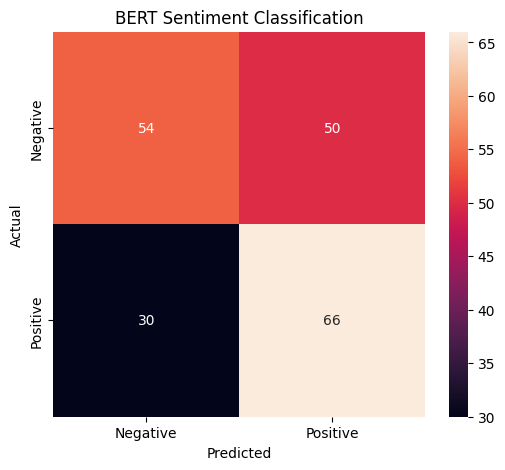

In [61]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Sentiment Classification")

plt.show()

In [62]:
def predict_sentiment(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()

    sentiment = "Positive" if predicted_class == 1 else "Negative"

    confidence = probabilities[0][predicted_class].item()

    return sentiment, confidence

In [64]:
import torch

In [65]:
text = "This movie was absolutely amazing. I loved every minute of it."

sentiment, confidence = predict_sentiment(text)

print("Review:", text)
print("Sentiment:", sentiment)
print(f"Confidence: {confidence:.2%}")

Review: This movie was absolutely amazing. I loved every minute of it.
Sentiment: Negative
Confidence: 55.54%


In [66]:
text = "This movie was boring and disappointing. I hated it."

sentiment, confidence = predict_sentiment(text)

print("Review:", text)
print("Sentiment:", sentiment)
print(f"Confidence: {confidence:.2%}")

Review: This movie was boring and disappointing. I hated it.
Sentiment: Negative
Confidence: 59.12%


In [1]:
from huggingface_hub import login
login()

In [4]:
from huggingface_hub import HfApi

api = HfApi()

api.create_repo(
    repo_id="Aimaaann/model-push",
    repo_type="model",
    exist_ok=True
)

print("Repository created successfully!")

Repository created successfully!


In [5]:
from huggingface_hub import login

login()